# Lung Cancer Survey — Comprehensive Medical Statistical Analysis

**Dataset**: Kaggle Lung Cancer Survey (309 observations, 16 variables)  
**Source**: https://www.kaggle.com/datasets/mysarahmadbhat/lung-cancer  
**Outcome**: LUNG_CANCER (YES/NO)  
**Analysis**: Descriptive statistics, chi-square tests, t-test/nonparametric tests, multivariable logistic regression, ROC/AUC analysis

## 1. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Reproducibility
np.random.seed(42)
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "figure.figsize": (8, 6),
})

# Output directories
BASE_DIR = Path("outputs/kaggle_survey")
TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Output directories ready.")
print(f"  Tables → {TABLE_DIR.resolve()}")
print(f"  Figures → {FIG_DIR.resolve()}")

Output directories ready.
  Tables → /Users/leigao/Documents/Python-Medical-Statistics-Skills/example/lung-cancer/analysis/outputs/kaggle_survey/tables
  Figures → /Users/leigao/Documents/Python-Medical-Statistics-Skills/example/lung-cancer/analysis/outputs/kaggle_survey/figures


## 2. Data Loading and Cleaning

Load the Kaggle lung cancer survey dataset. Binary variables are originally coded as 1=NO, 2=YES; recode to 0/1 for analysis.

In [2]:
DATA_PATH = Path("../data/survey lung cancer.csv")
df_raw = pd.read_csv(DATA_PATH)

print(f"Raw dataset: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")

# Fix trailing spaces in column names
df_raw.columns = df_raw.columns.str.strip()

# Recode binary variables: original 1=NO, 2=YES → 0/1
binary_vars = [
    "SMOKING", "YELLOW_FINGERS", "ANXIETY", "PEER_PRESSURE",
    "CHRONIC DISEASE", "FATIGUE", "ALLERGY", "WHEEZING",
    "ALCOHOL CONSUMING", "COUGHING", "SHORTNESS OF BREATH",
    "SWALLOWING DIFFICULTY", "CHEST PAIN",
]

df = df_raw.copy()
for col in binary_vars:
    df[col] = df[col].map({1: 0, 2: 1})

# Recode outcome and gender
df["LUNG_CANCER_BIN"] = df["LUNG_CANCER"].map({"YES": 1, "NO": 0})
df["GENDER_BIN"] = df["GENDER"].map({"M": 1, "F": 0})

print(f"\nMissing values: {df.isnull().sum().sum()} total")
print(f"\nOutcome distribution:")
print(df["LUNG_CANCER"].value_counts())
print(f"\nAge range: {df['AGE'].min()} – {df['AGE'].max()}, Mean: {df['AGE'].mean():.1f}")

Raw dataset: 309 rows × 16 columns

Missing values: 0 total

Outcome distribution:
LUNG_CANCER
YES    270
NO      39
Name: count, dtype: int64

Age range: 21 – 87, Mean: 62.7


## 3. Data Validation

In [3]:
print("=== Data Validation ===")
print("Binary variables range check (should be 0/1):")
for col in binary_vars:
    unique_vals = sorted(df[col].unique())
    status = "✓" if unique_vals == [0, 1] else "✗"
    print(f"  {status} {col}: {unique_vals}")

print(f"\nOutcome: {sorted(df['LUNG_CANCER_BIN'].unique())}")
print(f"Gender: {sorted(df['GENDER_BIN'].unique())}")
print(f"N(Lung Cancer=YES): {df['LUNG_CANCER_BIN'].sum()}, N(NO): {(df['LUNG_CANCER_BIN']==0).sum()}")

=== Data Validation ===
Binary variables range check (should be 0/1):
  ✓ SMOKING: [np.int64(0), np.int64(1)]
  ✓ YELLOW_FINGERS: [np.int64(0), np.int64(1)]
  ✓ ANXIETY: [np.int64(0), np.int64(1)]
  ✓ PEER_PRESSURE: [np.int64(0), np.int64(1)]
  ✓ CHRONIC DISEASE: [np.int64(0), np.int64(1)]
  ✓ FATIGUE: [np.int64(0), np.int64(1)]
  ✓ ALLERGY: [np.int64(0), np.int64(1)]
  ✓ WHEEZING: [np.int64(0), np.int64(1)]
  ✓ ALCOHOL CONSUMING: [np.int64(0), np.int64(1)]
  ✓ COUGHING: [np.int64(0), np.int64(1)]
  ✓ SHORTNESS OF BREATH: [np.int64(0), np.int64(1)]
  ✓ SWALLOWING DIFFICULTY: [np.int64(0), np.int64(1)]
  ✓ CHEST PAIN: [np.int64(0), np.int64(1)]

Outcome: [np.int64(0), np.int64(1)]
Gender: [np.int64(0), np.int64(1)]
N(Lung Cancer=YES): 270, N(NO): 39


## 4. Table 1: Descriptive Statistics by Lung Cancer Status

In [4]:
# Clinical labels
label_map = {
    "AGE": "Age, mean ± SD",
    "GENDER_BIN": "Male sex, n (%)",
    "SMOKING": "Smoking, n (%)",
    "YELLOW_FINGERS": "Yellow fingers, n (%)",
    "ANXIETY": "Anxiety, n (%)",
    "PEER_PRESSURE": "Peer pressure, n (%)",
    "CHRONIC DISEASE": "Chronic disease, n (%)",
    "FATIGUE": "Fatigue, n (%)",
    "ALLERGY": "Allergy, n (%)",
    "WHEEZING": "Wheezing, n (%)",
    "ALCOHOL CONSUMING": "Alcohol consuming, n (%)",
    "COUGHING": "Coughing, n (%)",
    "SHORTNESS OF BREATH": "Shortness of breath, n (%)",
    "SWALLOWING DIFFICULTY": "Swallowing difficulty, n (%)",
    "CHEST PAIN": "Chest pain, n (%)",
}

rows = []
all_categorical = ["GENDER_BIN"] + binary_vars

# Age (continuous)
for group_label, group_val in [("No Lung Cancer", 0), ("Lung Cancer", 1)]:
    subset = df.loc[df["LUNG_CANCER_BIN"] == group_val, "AGE"]
    rows.append({"Variable": "Age, mean ± SD", "Group": group_label,
                 "Value": f"{subset.mean():.1f} ± {subset.std():.1f}"})

# Binary variables
for var in all_categorical:
    for group_label, group_val in [("No Lung Cancer", 0), ("Lung Cancer", 1)]:
        subset = df.loc[df["LUNG_CANCER_BIN"] == group_val, var]
        n_yes = int(subset.sum())
        pct = 100 * n_yes / len(subset)
        rows.append({"Variable": label_map.get(var, var), "Group": group_label,
                     "Value": f"{n_yes} ({pct:.1f}%)"})

# Add N row
n_no = (df["LUNG_CANCER_BIN"] == 0).sum()
n_yes = (df["LUNG_CANCER_BIN"] == 1).sum()
rows.insert(0, {"Variable": "N", "Group": "No Lung Cancer", "Value": str(n_no)})
rows.insert(1, {"Variable": "N", "Group": "Lung Cancer", "Value": str(n_yes)})

table1 = pd.DataFrame(rows).pivot(index="Variable", columns="Group", values="Value")
table1 = table1[["No Lung Cancer", "Lung Cancer"]]

# Reorder
var_order = ["N", "Age, mean ± SD"] + [label_map.get(v, v) for v in all_categorical]
table1 = table1.reindex(var_order)

print("=== Table 1: Baseline Characteristics ===\n")
print(table1.to_string())
table1.to_csv(TABLE_DIR / "table1_descriptive.csv")
print(f"\nSaved: table1_descriptive.csv")

=== Table 1: Baseline Characteristics ===

Group                        No Lung Cancer  Lung Cancer
Variable                                                
N                                        39          270
Age, mean ± SD                   60.7 ± 9.6   63.0 ± 8.0
Male sex, n (%)                  17 (43.6%)  145 (53.7%)
Smoking, n (%)                   19 (48.7%)  155 (57.4%)
Yellow fingers, n (%)            13 (33.3%)  163 (60.4%)
Anxiety, n (%)                   12 (30.8%)  142 (52.6%)
Peer pressure, n (%)             10 (25.6%)  145 (53.7%)
Chronic disease, n (%)           14 (35.9%)  142 (52.6%)
Fatigue, n (%)                   19 (48.7%)  189 (70.0%)
Allergy, n (%)                    5 (12.8%)  167 (61.9%)
Wheezing, n (%)                   9 (23.1%)  163 (60.4%)
Alcohol consuming, n (%)          7 (17.9%)  165 (61.1%)
Coughing, n (%)                  10 (25.6%)  169 (62.6%)
Shortness of breath, n (%)       22 (56.4%)  176 (65.2%)
Swallowing difficulty, n (%)      5 (12.8%)  

## 5. Chi-Square / Fisher Exact Tests

Test association between each categorical risk factor and lung cancer status.

In [5]:
chi2_results = []

for var in all_categorical:
    observed = pd.crosstab(df[var], df["LUNG_CANCER_BIN"])
    chi2, p_value, dof, expected = stats.chi2_contingency(observed)

    # Use Fisher exact for 2x2 tables with small expected counts
    method = "Chi-square"
    if observed.shape == (2, 2) and (expected < 5).any():
        _, p_value = stats.fisher_exact(observed)
        method = "Fisher exact"

    prop_cancer = df.loc[df["LUNG_CANCER_BIN"] == 1, var].mean()
    prop_no_cancer = df.loc[df["LUNG_CANCER_BIN"] == 0, var].mean()

    chi2_results.append({
        "Variable": label_map.get(var, var),
        "Prop_LungCancer": f"{prop_cancer:.1%}",
        "Prop_NoLungCancer": f"{prop_no_cancer:.1%}",
        "Test": method,
        "Chi2": round(chi2, 3) if method == "Chi-square" else None,
        "p_value": p_value,
        "p_formatted": f"{p_value:.4f}" if p_value >= 0.0001 else "<0.0001",
        "Significant": "Yes" if p_value < 0.05 else "No",
    })

chi2_df = pd.DataFrame(chi2_results)
display_cols = ["Variable", "Prop_LungCancer", "Prop_NoLungCancer", "Test", "p_formatted", "Significant"]
print("=== Chi-Square / Fisher Exact Tests ===\n")
print(chi2_df[display_cols].to_string(index=False))
chi2_df.to_csv(TABLE_DIR / "chi_square_tests.csv", index=False)
print(f"\nSaved: chi_square_tests.csv")

=== Chi-Square / Fisher Exact Tests ===

                    Variable Prop_LungCancer Prop_NoLungCancer       Test p_formatted Significant
             Male sex, n (%)           53.7%             43.6% Chi-square      0.3122          No
              Smoking, n (%)           57.4%             48.7% Chi-square      0.3953          No
       Yellow fingers, n (%)           60.4%             33.3% Chi-square      0.0026         Yes
              Anxiety, n (%)           52.6%             30.8% Chi-square      0.0175         Yes
        Peer pressure, n (%)           53.7%             25.6% Chi-square      0.0019         Yes
      Chronic disease, n (%)           52.6%             35.9% Chi-square      0.0754          No
              Fatigue, n (%)           70.0%             48.7% Chi-square      0.0137         Yes
              Allergy, n (%)           61.9%             12.8% Chi-square     <0.0001         Yes
             Wheezing, n (%)           60.4%             23.1% Chi-square    

## 6. Age Comparison: T-Test and Nonparametric Test

In [6]:
age_cancer = df.loc[df["LUNG_CANCER_BIN"] == 1, "AGE"].dropna()
age_no_cancer = df.loc[df["LUNG_CANCER_BIN"] == 0, "AGE"].dropna()

print(f"Lung Cancer (n={len(age_cancer)}): Mean={age_cancer.mean():.1f}, SD={age_cancer.std():.1f}")
print(f"No Lung Cancer (n={len(age_no_cancer)}): Mean={age_no_cancer.mean():.1f}, SD={age_no_cancer.std():.1f}")

# Normality check
_, p_norm_cancer = stats.shapiro(age_cancer)
_, p_norm_no = stats.shapiro(age_no_cancer)
print(f"\nShapiro-Wilk normality: Cancer p={p_norm_cancer:.4f}, No Cancer p={p_norm_no:.4f}")

# Welch's t-test
t_stat, t_pvalue = stats.ttest_ind(age_cancer, age_no_cancer, equal_var=False)
mean_diff = age_cancer.mean() - age_no_cancer.mean()
print(f"\nWelch t-test: t={t_stat:.3f}, p={t_pvalue:.4f}, Mean diff={mean_diff:.2f}")

# Mann-Whitney U
u_stat, u_pvalue = stats.mannwhitneyu(age_cancer, age_no_cancer, alternative="two-sided")
print(f"Mann-Whitney U: U={u_stat:.1f}, p={u_pvalue:.4f}")

# Save
age_results = pd.DataFrame([{
    "Variable": "Age",
    "Cancer_Mean_SD": f"{age_cancer.mean():.1f} ± {age_cancer.std():.1f}",
    "NoCancer_Mean_SD": f"{age_no_cancer.mean():.1f} ± {age_no_cancer.std():.1f}",
    "Mean_Difference": round(mean_diff, 2),
    "Welch_t": round(t_stat, 3),
    "Welch_p": round(t_pvalue, 4),
    "MannWhitney_U": round(u_stat, 1),
    "MannWhitney_p": round(u_pvalue, 4),
}])
age_results.to_csv(TABLE_DIR / "age_ttest_results.csv", index=False)
print(f"\nSaved: age_ttest_results.csv")

Lung Cancer (n=270): Mean=63.0, SD=8.0
No Lung Cancer (n=39): Mean=60.7, SD=9.6

Shapiro-Wilk normality: Cancer p=0.0599, No Cancer p=0.0000

Welch t-test: t=1.366, p=0.1785, Mean diff=2.21
Mann-Whitney U: U=5960.5, p=0.1823

Saved: age_ttest_results.csv


## 7. Figure 1: Age Distribution by Lung Cancer Status

/var/folders/b_/zsmfd3sn39b09w6f38gjzxqw0000gn/T/ipykernel_11005/2122390221.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="LUNG_CANCER", y="AGE", palette=["#4ECDC4", "#FF6B6B"], ax=ax)


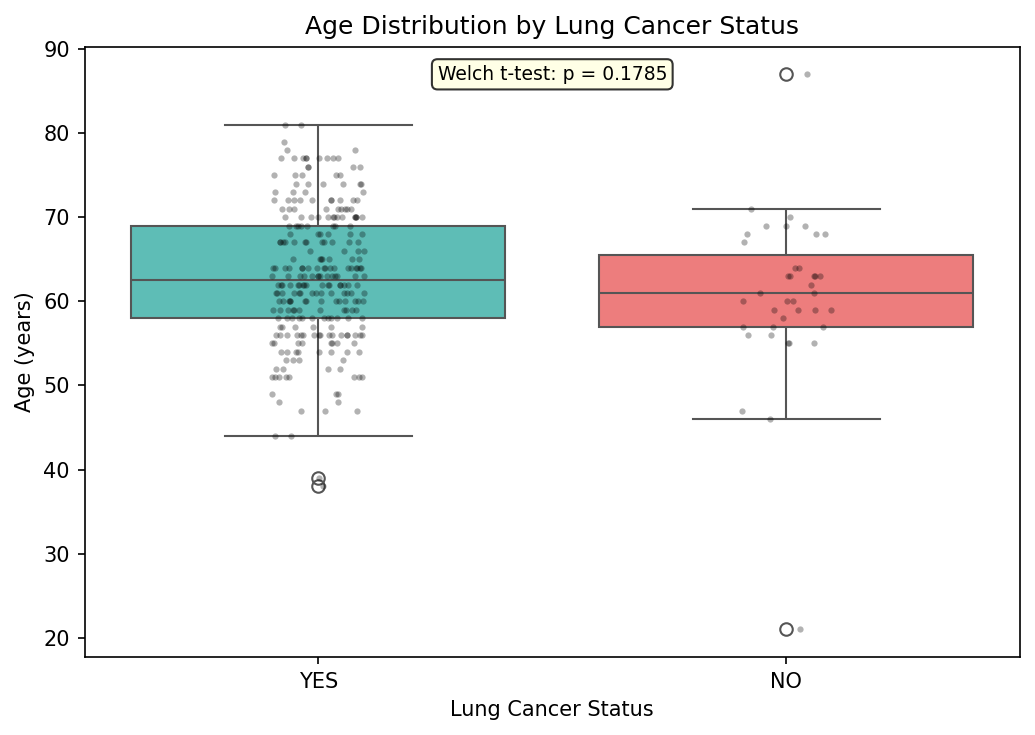

Saved: fig1_age_boxplot.png


In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="LUNG_CANCER", y="AGE", palette=["#4ECDC4", "#FF6B6B"], ax=ax)
sns.stripplot(data=df, x="LUNG_CANCER", y="AGE", color="black", alpha=0.3, size=3, jitter=True, ax=ax)
ax.set_xlabel("Lung Cancer Status")
ax.set_ylabel("Age (years)")
ax.set_title("Age Distribution by Lung Cancer Status")

sig_text = f"Welch t-test: p = {t_pvalue:.4f}" if t_pvalue >= 0.0001 else "Welch t-test: p < 0.0001"
ax.text(0.5, 0.97, sig_text, transform=ax.transAxes, ha="center", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_age_boxplot.png", bbox_inches="tight")
plt.show()
print(f"Saved: fig1_age_boxplot.png")

## 8. Multivariable Logistic Regression

Fit a logistic regression model with all risk factors as predictors. Report adjusted odds ratios with 95% confidence intervals.

In [8]:
# Prepare predictors with clean column names (no spaces for formula)
predictor_cols = ["AGE", "GENDER_BIN"] + binary_vars
df_model = df[predictor_cols + ["LUNG_CANCER_BIN"]].copy()
df_model.columns = [c.replace(" ", "_") for c in df_model.columns]
predictor_cols_clean = [c.replace(" ", "_") for c in predictor_cols]

# Fit logistic regression
formula = "LUNG_CANCER_BIN ~ " + " + ".join(predictor_cols_clean)
print(f"Formula: {formula}\n")

model = smf.logit(formula, data=df_model).fit(disp=0)

# Extract odds ratios with 95% CI
params = model.params
conf = model.conf_int()
or_df = pd.DataFrame({
    "Variable": params.index,
    "OR": np.exp(params.values),
    "OR_CI_low": np.exp(conf.iloc[:, 0].values),
    "OR_CI_high": np.exp(conf.iloc[:, 1].values),
    "p_value": model.pvalues.values,
})

or_df = or_df[or_df["Variable"] != "Intercept"].reset_index(drop=True)
or_df["OR_formatted"] = or_df.apply(
    lambda r: f"{r['OR']:.2f} ({r['OR_CI_low']:.2f}–{r['OR_CI_high']:.2f})", axis=1
)
or_df["p_formatted"] = or_df["p_value"].apply(lambda p: f"{p:.4f}" if p >= 0.0001 else "<0.0001")
or_df["Significant"] = or_df["p_value"].apply(lambda p: "Yes" if p < 0.05 else "No")

# Readable labels
var_label_map = {c.replace(" ", "_"): label_map.get(c, c) for c in predictor_cols}
var_label_map["AGE"] = "Age (per year)"
var_label_map["GENDER_BIN"] = "Male sex"
or_df["Label"] = or_df["Variable"].map(var_label_map)

print("=== Adjusted Odds Ratios ===\n")
print(or_df[["Label", "OR_formatted", "p_formatted", "Significant"]].to_string(index=False))
print(f"\nModel: AIC={model.aic:.1f}, Pseudo R²={model.prsquared:.4f}")

or_df.to_csv(TABLE_DIR / "logistic_regression_ORs.csv", index=False)
print(f"\nSaved: logistic_regression_ORs.csv")

Formula: LUNG_CANCER_BIN ~ AGE + GENDER_BIN + SMOKING + YELLOW_FINGERS + ANXIETY + PEER_PRESSURE + CHRONIC_DISEASE + FATIGUE + ALLERGY + WHEEZING + ALCOHOL_CONSUMING + COUGHING + SHORTNESS_OF_BREATH + SWALLOWING_DIFFICULTY + CHEST_PAIN

=== Adjusted Odds Ratios ===

                       Label        OR_formatted p_formatted Significant
              Age (per year)    1.02 (0.96–1.09)      0.5205          No
                    Male sex    0.59 (0.15–2.37)      0.4581          No
              Smoking, n (%)   5.91 (1.49–23.38)      0.0114         Yes
       Yellow fingers, n (%)   3.96 (0.92–16.97)      0.0638          No
              Anxiety, n (%)   2.43 (0.49–11.95)      0.2747          No
        Peer pressure, n (%)   5.65 (1.55–20.60)      0.0087         Yes
      Chronic disease, n (%) 24.33 (4.27–138.74)      0.0003         Yes
              Fatigue, n (%) 21.55 (4.28–108.61)      0.0002         Yes
              Allergy, n (%)   5.19 (1.15–23.41)      0.0323         Yes
   

## 9. Figure 2: Forest Plot of Odds Ratios

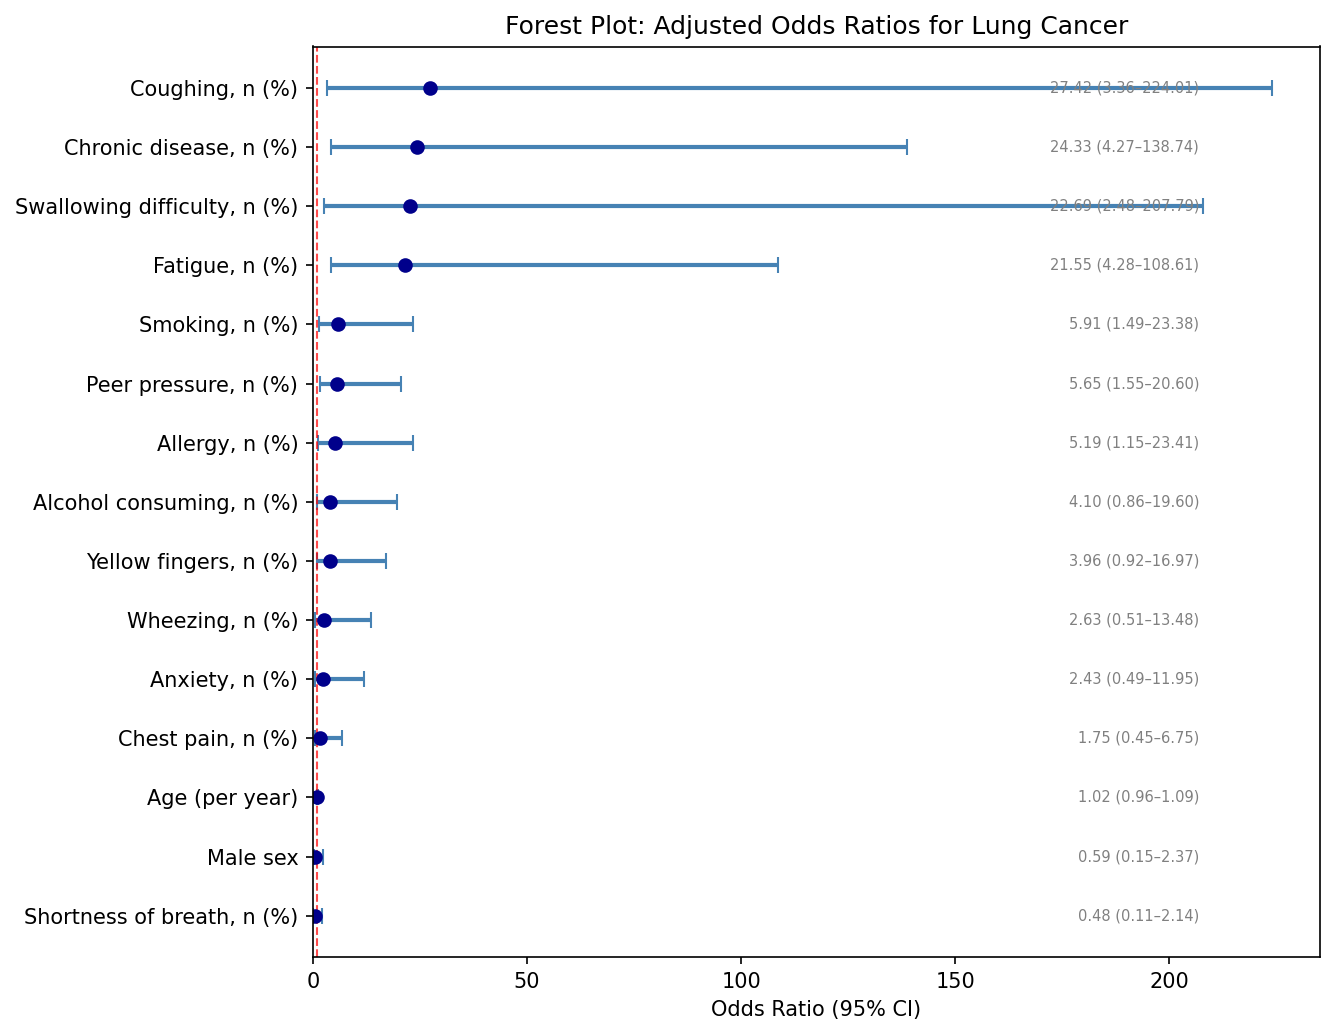

Saved: fig2_forest_plot_OR.png


In [9]:
fig, ax = plt.subplots(figsize=(9, 7))

or_plot = or_df.sort_values("OR", ascending=True).reset_index(drop=True)
y_pos = range(len(or_plot))

ax.errorbar(
    or_plot["OR"], y_pos,
    xerr=[or_plot["OR"] - or_plot["OR_CI_low"], or_plot["OR_CI_high"] - or_plot["OR"]],
    fmt="o", color="darkblue", ecolor="steelblue", elinewidth=2, capsize=4, markersize=6,
)

ax.axvline(x=1, color="red", linestyle="--", linewidth=1, alpha=0.7)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(or_plot["Label"])
ax.set_xlabel("Odds Ratio (95% CI)")
ax.set_title("Forest Plot: Adjusted Odds Ratios for Lung Cancer")
ax.set_xlim(left=0)

# Annotate OR values
for i, row in or_plot.iterrows():
    idx = or_plot.index.get_loc(i)
    ax.text(ax.get_xlim()[1] * 0.88, idx, row["OR_formatted"],
            va="center", ha="right", fontsize=7, color="gray")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_forest_plot_OR.png", bbox_inches="tight")
plt.show()
print(f"Saved: fig2_forest_plot_OR.png")

## 10. ROC / AUC Analysis

Evaluate model discrimination with apparent AUC and 5-fold cross-validated AUC. Identify optimal threshold using Youden's J statistic.

In [10]:
# Predicted probabilities from the fitted model
y_true = df_model["LUNG_CANCER_BIN"].values
y_pred_prob = model.predict(df_model[predictor_cols_clean])

# Apparent AUC (training)
auc_train = roc_auc_score(y_true, y_pred_prob)
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
print(f"Apparent AUC (training): {auc_train:.4f}")

# Cross-validated AUC (internal validation)
X = df_model[predictor_cols_clean].values
y = df_model["LUNG_CANCER_BIN"].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_sklearn = LogisticRegression(max_iter=1000, random_state=42)
y_cv_prob = cross_val_predict(lr_sklearn, X, y, cv=cv, method="predict_proba")[:, 1]
auc_cv = roc_auc_score(y, y_cv_prob)
fpr_cv, tpr_cv, _ = roc_curve(y, y_cv_prob)
print(f"Cross-validated AUC (5-fold): {auc_cv:.4f}")

# Optimal threshold (Youden's J)
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_sens = tpr[optimal_idx]
optimal_spec = 1 - fpr[optimal_idx]
print(f"\nOptimal threshold (Youden's J): {optimal_threshold:.4f}")
print(f"  Sensitivity: {optimal_sens:.4f}")
print(f"  Specificity: {optimal_spec:.4f}")

# Save results
auc_summary = pd.DataFrame([{
    "AUC_apparent": round(auc_train, 4),
    "AUC_CV_5fold": round(auc_cv, 4),
    "Optimal_threshold": round(optimal_threshold, 4),
    "Sensitivity": round(optimal_sens, 4),
    "Specificity": round(optimal_spec, 4),
}])
auc_summary.to_csv(TABLE_DIR / "auc_summary.csv", index=False)

roc_table = pd.DataFrame({"Threshold": thresholds, "Sensitivity": tpr, "Specificity": 1 - fpr})
roc_table.to_csv(TABLE_DIR / "roc_threshold_table.csv", index=False)
print(f"\nSaved: auc_summary.csv, roc_threshold_table.csv")

Apparent AUC (training): 0.9674
Cross-validated AUC (5-fold): 0.9397

Optimal threshold (Youden's J): 0.8716
  Sensitivity: 0.9037
  Specificity: 0.9487

Saved: auc_summary.csv, roc_threshold_table.csv


## 11. Figure 3: ROC Curve

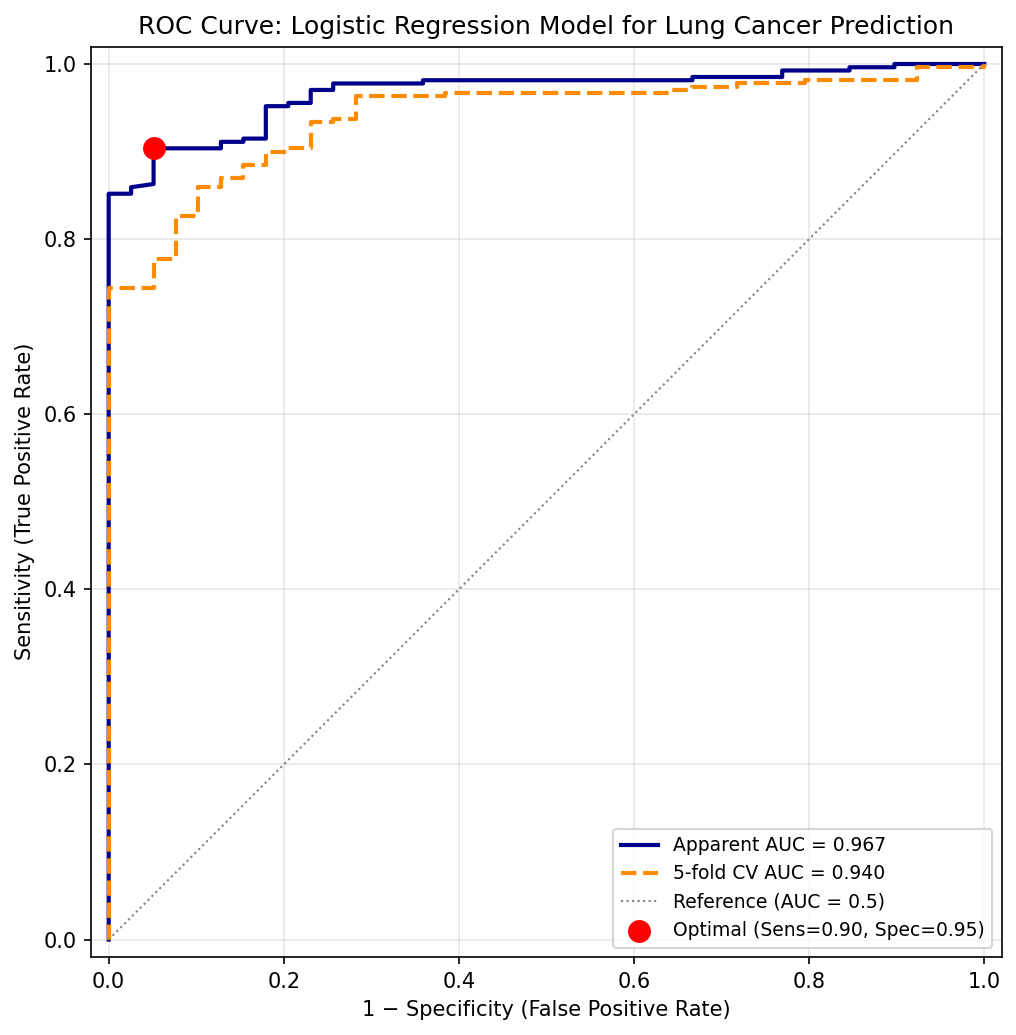

Saved: fig3_roc_curve.png


In [11]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.plot(fpr, tpr, color="darkblue", linewidth=2, label=f"Apparent AUC = {auc_train:.3f}")
ax.plot(fpr_cv, tpr_cv, color="darkorange", linewidth=2, linestyle="--",
        label=f"5-fold CV AUC = {auc_cv:.3f}")
ax.plot([0, 1], [0, 1], color="gray", linestyle=":", linewidth=1, label="Reference (AUC = 0.5)")
ax.scatter([fpr[optimal_idx]], [tpr[optimal_idx]], color="red", s=100, zorder=5,
           label=f"Optimal (Sens={optimal_sens:.2f}, Spec={optimal_spec:.2f})")

ax.set_xlabel("1 − Specificity (False Positive Rate)")
ax.set_ylabel("Sensitivity (True Positive Rate)")
ax.set_title("ROC Curve: Logistic Regression Model for Lung Cancer Prediction")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_roc_curve.png", bbox_inches="tight")
plt.show()
print(f"Saved: fig3_roc_curve.png")

## 12. Analysis Summary

In [12]:
print("=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)
print(f"\nDataset: {DATA_PATH.name}")
print(f"N = {len(df)} observations")
print(f"Outcome: Lung Cancer YES={df['LUNG_CANCER_BIN'].sum()}, NO={(df['LUNG_CANCER_BIN']==0).sum()}")

print(f"\nKey findings:")
print(f"  • Age: {'No significant difference' if t_pvalue >= 0.05 else 'Significant difference'} (p={t_pvalue:.4f})")

sig_vars = chi2_df[chi2_df["p_value"] < 0.05]["Variable"].tolist()
print(f"  • Significant univariate associations ({len(sig_vars)}): {', '.join(sig_vars)}")

sig_or = or_df[or_df["p_value"] < 0.05]
print(f"  • Significant adjusted predictors ({len(sig_or)}):")
for _, row in sig_or.iterrows():
    print(f"      {row['Label']}: OR={row['OR']:.2f} [{row['OR_CI_low']:.2f}–{row['OR_CI_high']:.2f}], p={row['p_value']:.4f}")

print(f"  • Model AUC: {auc_train:.3f} (apparent), {auc_cv:.3f} (5-fold CV)")

print(f"\nOutputs:")
for f in sorted(TABLE_DIR.glob("*.csv")):
    print(f"  📄 {f.relative_to(BASE_DIR)}")
for f in sorted(FIG_DIR.glob("*.png")):
    print(f"  📊 {f.relative_to(BASE_DIR)}")

ANALYSIS COMPLETE

Dataset: survey lung cancer.csv
N = 309 observations
Outcome: Lung Cancer YES=270, NO=39

Key findings:
  • Age: No significant difference (p=0.1785)
  • Significant univariate associations (10): Yellow fingers, n (%), Anxiety, n (%), Peer pressure, n (%), Fatigue, n (%), Allergy, n (%), Wheezing, n (%), Alcohol consuming, n (%), Coughing, n (%), Swallowing difficulty, n (%), Chest pain, n (%)
  • Significant adjusted predictors (7):
      Smoking, n (%): OR=5.91 [1.49–23.38], p=0.0114
      Peer pressure, n (%): OR=5.65 [1.55–20.60], p=0.0087
      Chronic disease, n (%): OR=24.33 [4.27–138.74], p=0.0003
      Fatigue, n (%): OR=21.55 [4.28–108.61], p=0.0002
      Allergy, n (%): OR=5.19 [1.15–23.41], p=0.0323
      Coughing, n (%): OR=27.42 [3.36–224.01], p=0.0020
      Swallowing difficulty, n (%): OR=22.69 [2.48–207.79], p=0.0057
  • Model AUC: 0.967 (apparent), 0.940 (5-fold CV)

Outputs:
  📄 tables/age_ttest_results.csv
  📄 tables/auc_summary.csv
  📄 tables/chi

## 13. Correlation Heatmap (Phi Coefficients)

Compute pairwise phi coefficients (equivalent to Pearson r for binary variables) to visualize intercorrelations among risk factors.

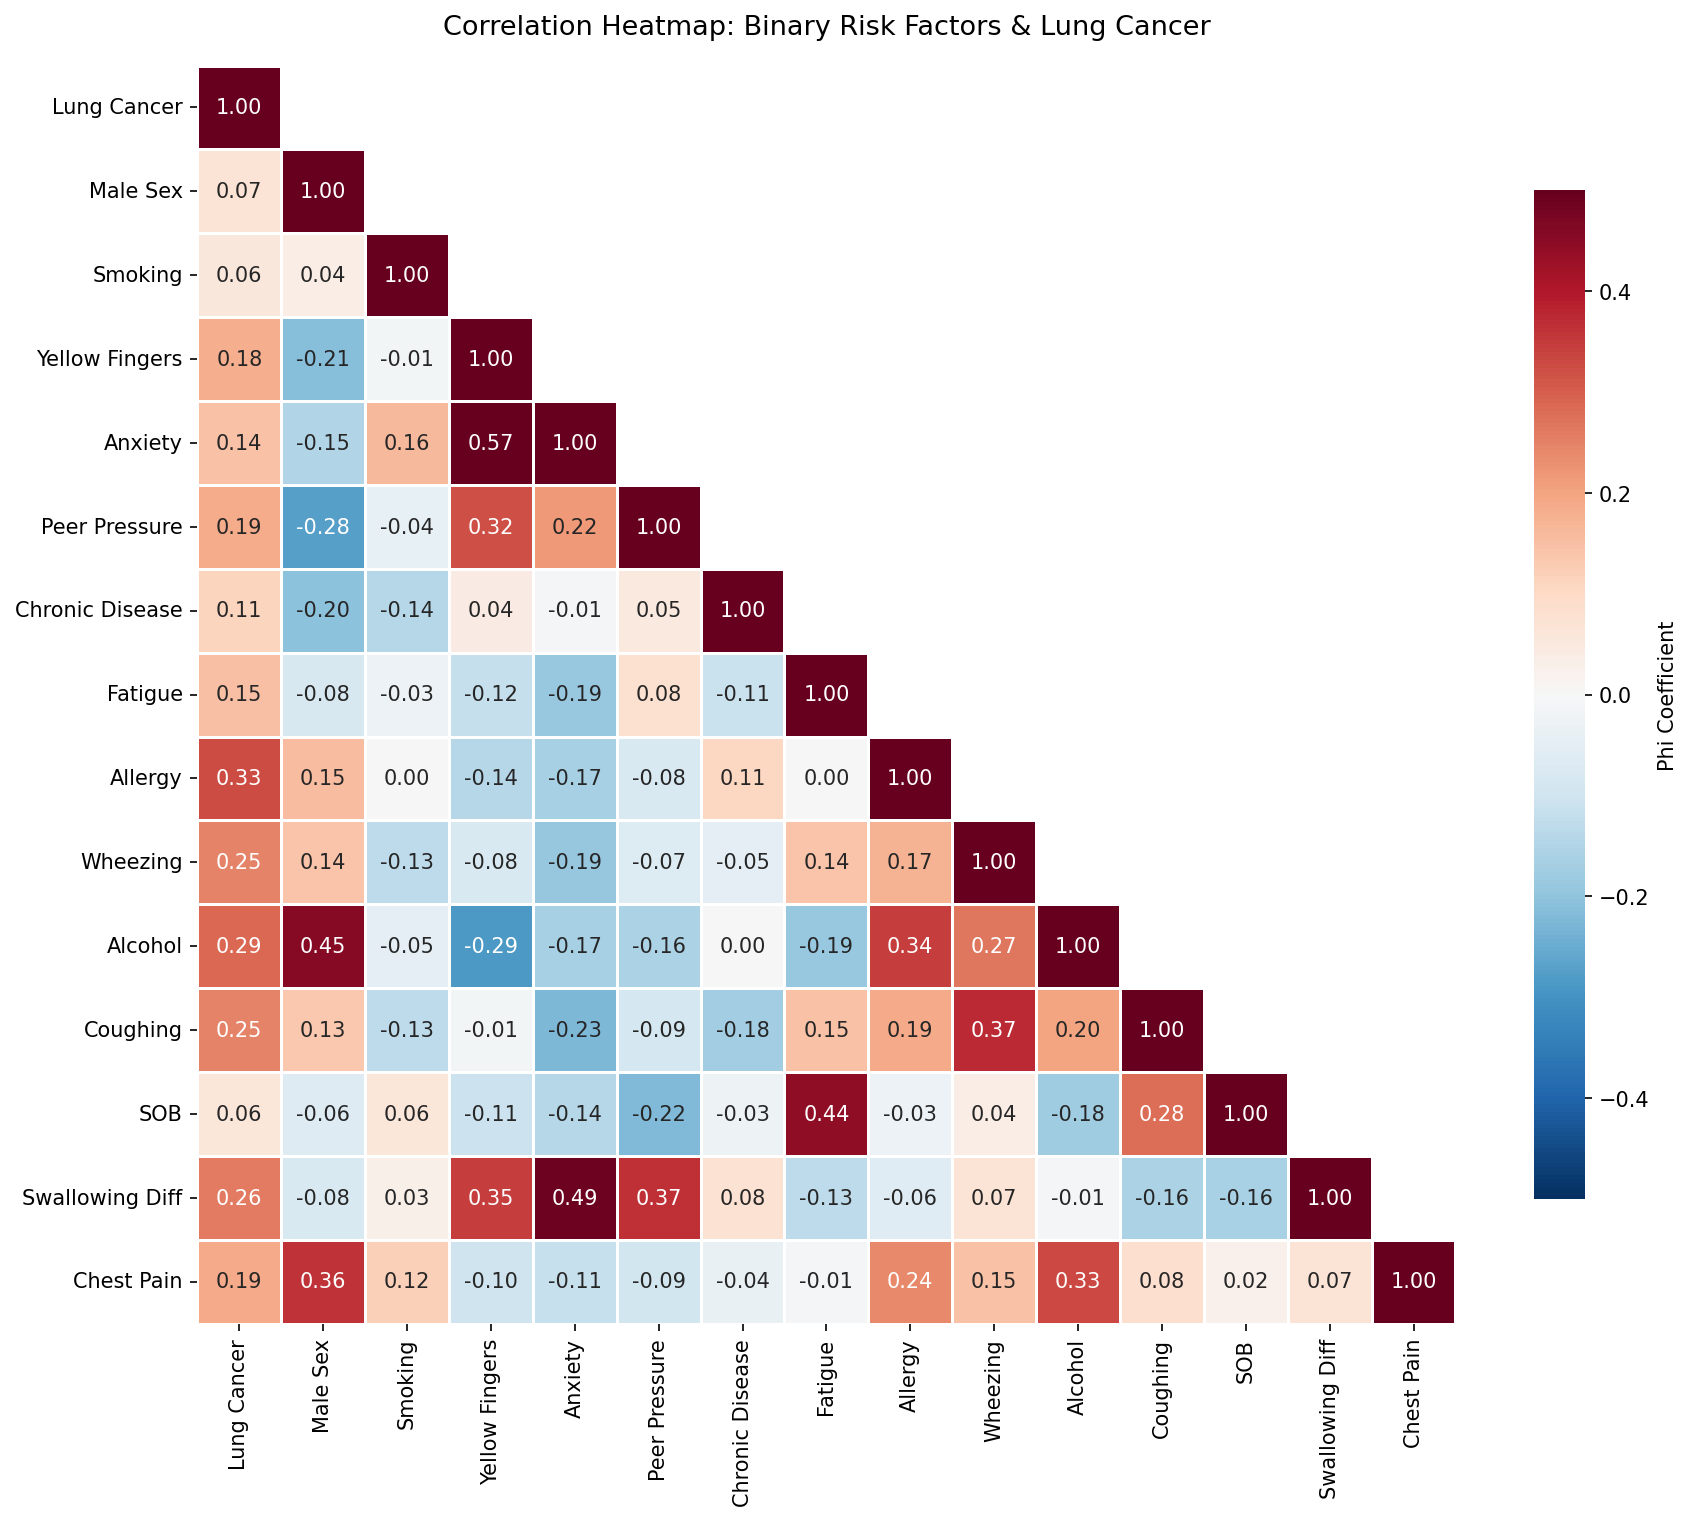

Saved: fig4_correlation_heatmap.png


In [13]:
# Compute correlation matrix for all binary predictors + outcome
corr_vars = ["LUNG_CANCER_BIN", "GENDER_BIN"] + binary_vars
corr_labels = ["Lung Cancer", "Male Sex", "Smoking", "Yellow Fingers", "Anxiety",
               "Peer Pressure", "Chronic Disease", "Fatigue", "Allergy", "Wheezing",
               "Alcohol", "Coughing", "SOB", "Swallowing Diff", "Chest Pain"]

corr_matrix = df[corr_vars].corr()
corr_matrix.index = corr_labels
corr_matrix.columns = corr_labels

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-0.5, vmax=0.5, center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Phi Coefficient"}, ax=ax)
ax.set_title("Correlation Heatmap: Binary Risk Factors & Lung Cancer", fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_correlation_heatmap.png", bbox_inches="tight")
plt.show()
print(f"Saved: fig4_correlation_heatmap.png")

## 14. PCA: Dimensionality Reduction of Risk Factors

Apply Principal Component Analysis to explore the latent structure of the 15 predictors (age + 14 binary). Visualize the first two principal components colored by lung cancer status.

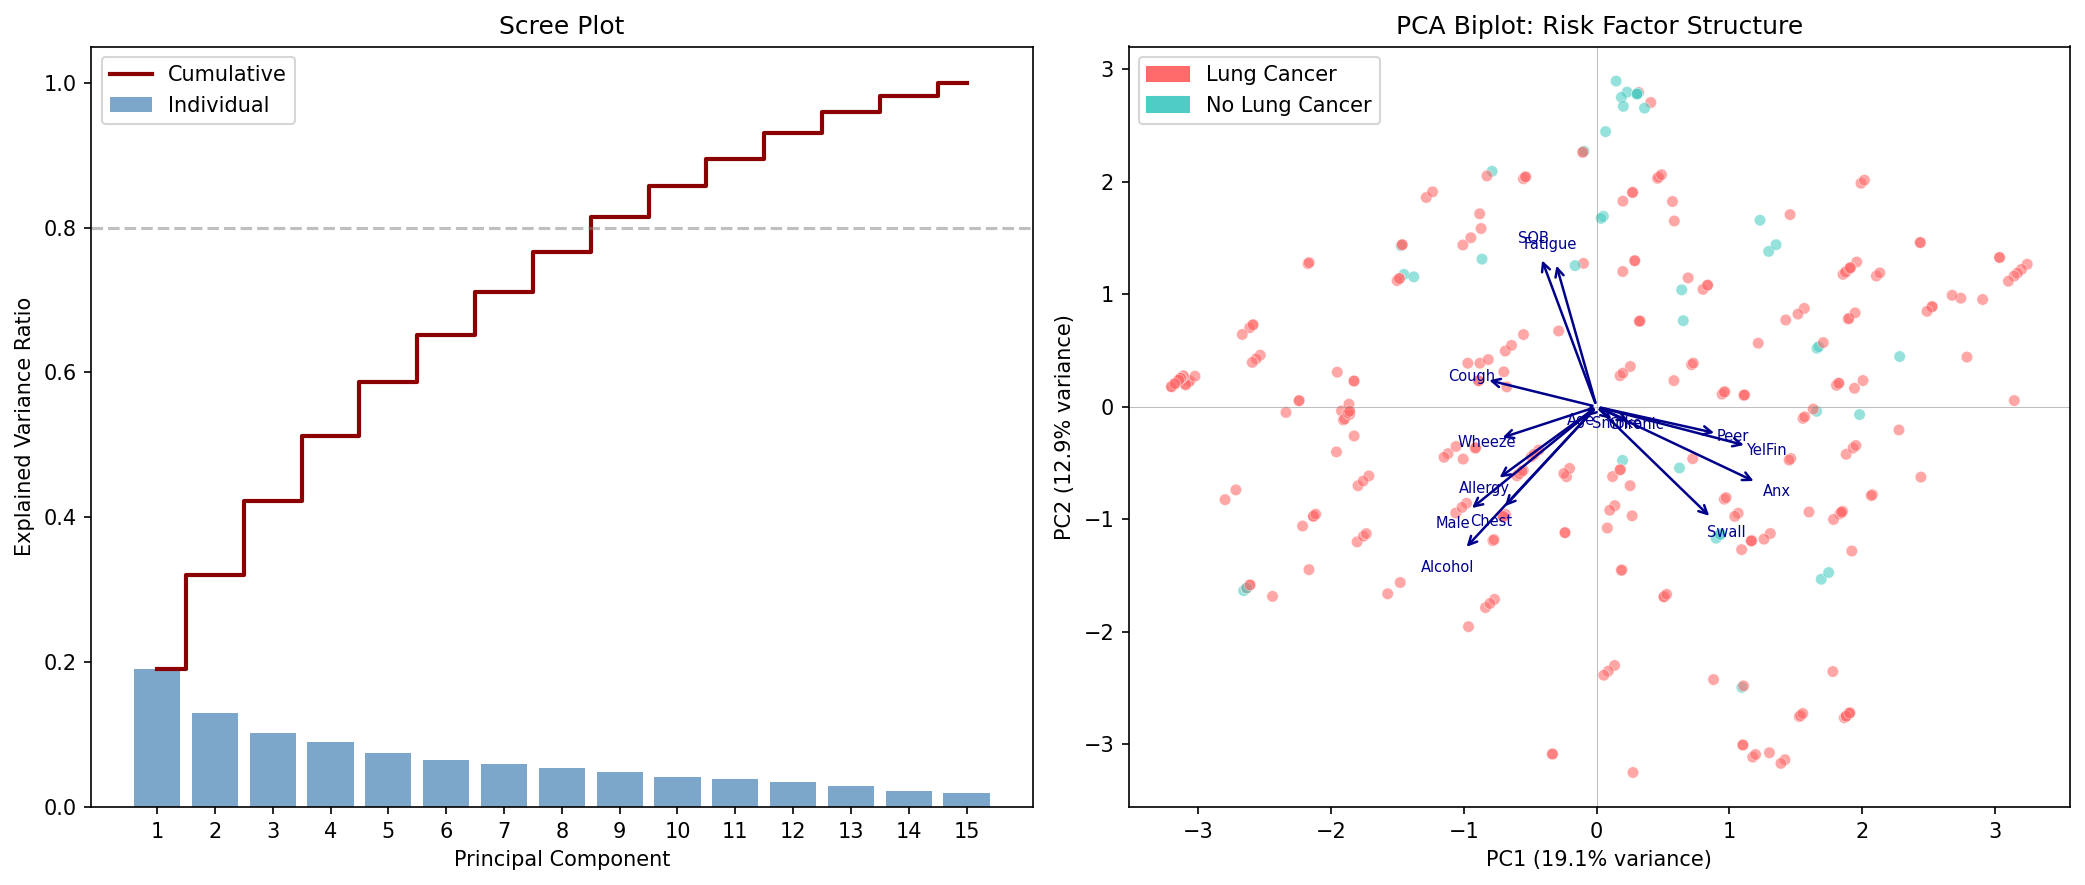

Variance explained by first 5 PCs: 58.7%

Top PC1 loadings:
Anx        0.403638
YelFin     0.379757
Alcohol   -0.333769
Male      -0.321176
Peer       0.305393


In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize all predictors
feature_names = ["AGE", "GENDER_BIN"] + binary_vars
X_pca = df[feature_names].copy()
X_scaled = StandardScaler().fit_transform(X_pca)

# Fit PCA
pca = PCA(random_state=42)
scores = pca.fit_transform(X_scaled)

# Scree plot + biplot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Scree plot
cumvar = np.cumsum(pca.explained_variance_ratio_)
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1),
            pca.explained_variance_ratio_, alpha=0.7, color="steelblue", label="Individual")
axes[0].step(range(1, len(cumvar) + 1), cumvar, where="mid", color="darkred",
             linewidth=2, label="Cumulative")
axes[0].axhline(y=0.8, color="gray", linestyle="--", alpha=0.5)
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Scree Plot")
axes[0].legend()
axes[0].set_xticks(range(1, len(pca.explained_variance_ratio_) + 1))

# Right: PC1 vs PC2 biplot
colors = df["LUNG_CANCER_BIN"].map({0: "#4ECDC4", 1: "#FF6B6B"})
axes[1].scatter(scores[:, 0], scores[:, 1], c=colors, alpha=0.6, s=30, edgecolors="white", linewidth=0.3)

# Add loading arrows
loadings = pca.components_[:2, :].T
scale_factor = 3
short_names = ["Age", "Male", "Smoke", "YelFin", "Anx", "Peer", "Chronic",
               "Fatigue", "Allergy", "Wheeze", "Alcohol", "Cough", "SOB", "Swall", "Chest"]
for i, (name, loading) in enumerate(zip(short_names, loadings)):
    axes[1].annotate("", xy=(loading[0]*scale_factor, loading[1]*scale_factor), xytext=(0, 0),
                     arrowprops=dict(arrowstyle="->", color="darkblue", lw=1.2))
    axes[1].text(loading[0]*scale_factor*1.12, loading[1]*scale_factor*1.12, name,
                 fontsize=7, ha="center", va="center", color="darkblue")

# Legend
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color="#FF6B6B", label="Lung Cancer"),
                        Patch(color="#4ECDC4", label="No Lung Cancer")], loc="upper left")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
axes[1].set_title("PCA Biplot: Risk Factor Structure")
axes[1].axhline(0, color="gray", linewidth=0.5, alpha=0.5)
axes[1].axvline(0, color="gray", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig5_pca_biplot.png", bbox_inches="tight")
plt.show()

# Print variance explained
print(f"Variance explained by first 5 PCs: {cumvar[4]:.1%}")
print(f"\nTop PC1 loadings:")
pc1_load = pd.Series(pca.components_[0], index=short_names).sort_values(key=abs, ascending=False)
print(pc1_load.head(5).to_string())

## 15. Subgroup Analysis: Treatment Effect by Gender and Age

Estimate the association between smoking and lung cancer stratified by gender and age group, with interaction p-values. Present results as a forest plot.

=== Subgroup Analysis: Smoking OR for Lung Cancer ===

 Subgroup   N  Events       OR   CI_low  CI_high  p_value
  Overall 309     270 1.494094 0.757622 2.946478 0.246517
     Male 162     145 1.267842 0.460034 3.494141 0.646369
   Female 147     125 1.664776 0.658159 4.210953 0.281711
  Age ≤55  50      44 1.056982 0.164866 6.776462 0.953384
Age 56–65 153     130 2.108261 0.850321 5.227158 0.107403
  Age >65 106      96 0.758865 0.199911 2.880661 0.685166

Interaction p-values:
  Smoking × Gender: p = 0.6747
  Smoking × Age (continuous): p = 0.9860


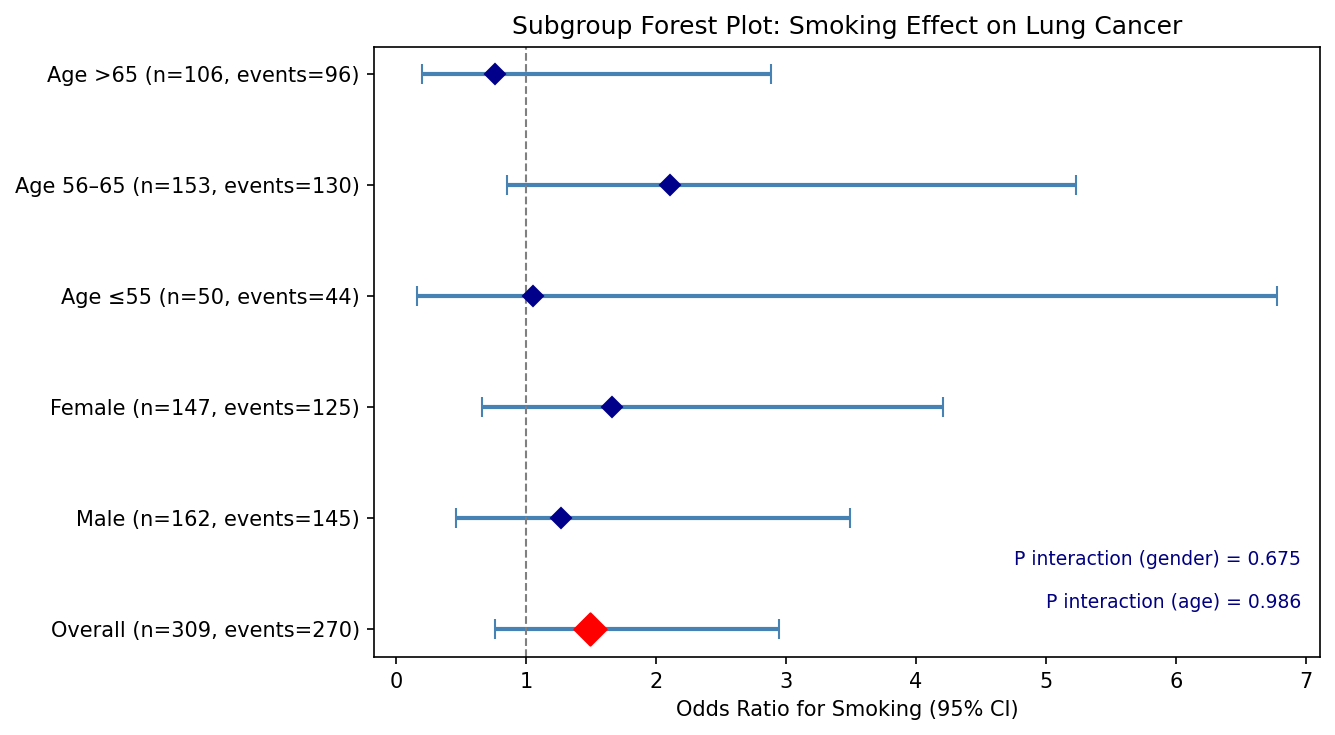


Saved: fig6_subgroup_forest.png


In [15]:
# Create age groups
df["AGE_GROUP"] = pd.cut(df["AGE"], bins=[0, 55, 65, 100], labels=["≤55", "56–65", ">65"])

# Define subgroup dimensions
subgroup_defs = [
    ("Overall", df),
    ("Male", df[df["GENDER"] == "M"]),
    ("Female", df[df["GENDER"] == "F"]),
    ("Age ≤55", df[df["AGE_GROUP"] == "≤55"]),
    ("Age 56–65", df[df["AGE_GROUP"] == "56–65"]),
    ("Age >65", df[df["AGE_GROUP"] == ">65"]),
]

# Fit logistic regression in each subgroup for SMOKING effect
subgroup_rows = []
for name, subset in subgroup_defs:
    if subset["LUNG_CANCER_BIN"].nunique() < 2 or subset["SMOKING"].nunique() < 2:
        continue
    try:
        sub_model = smf.logit("LUNG_CANCER_BIN ~ SMOKING + AGE", data=subset).fit(disp=0)
        or_val = np.exp(sub_model.params["SMOKING"])
        ci = np.exp(sub_model.conf_int().loc["SMOKING"])
        subgroup_rows.append({
            "Subgroup": name, "N": len(subset),
            "Events": int(subset["LUNG_CANCER_BIN"].sum()),
            "OR": or_val, "CI_low": ci.iloc[0], "CI_high": ci.iloc[1],
            "p_value": sub_model.pvalues["SMOKING"],
        })
    except Exception:
        pass

# Interaction tests
int_model_gender = smf.logit("LUNG_CANCER_BIN ~ SMOKING * GENDER_BIN + AGE", data=df).fit(disp=0)
int_model_age = smf.logit("LUNG_CANCER_BIN ~ SMOKING * AGE + GENDER_BIN", data=df).fit(disp=0)
p_int_gender = int_model_gender.pvalues.get("SMOKING:GENDER_BIN", np.nan)
p_int_age = int_model_age.pvalues.get("SMOKING:AGE", np.nan)

subgroup_df = pd.DataFrame(subgroup_rows)
print("=== Subgroup Analysis: Smoking OR for Lung Cancer ===\n")
print(subgroup_df.to_string(index=False))
print(f"\nInteraction p-values:")
print(f"  Smoking × Gender: p = {p_int_gender:.4f}")
print(f"  Smoking × Age (continuous): p = {p_int_age:.4f}")

# Forest plot
fig, ax = plt.subplots(figsize=(9, 5))
y_pos = range(len(subgroup_df))
colors = ["black"] + ["#2196F3"]*2 + ["#4CAF50"]*3

ax.errorbar(subgroup_df["OR"], y_pos,
            xerr=[subgroup_df["OR"] - subgroup_df["CI_low"],
                  subgroup_df["CI_high"] - subgroup_df["OR"]],
            fmt="D", color="darkblue", ecolor="steelblue", elinewidth=2,
            capsize=5, markersize=7)

# Highlight overall with different marker
ax.scatter(subgroup_df.iloc[0]["OR"], 0, marker="D", s=120, color="red", zorder=10)

ax.axvline(x=1, color="gray", linestyle="--", linewidth=1)
ax.set_yticks(list(y_pos))
ax.set_yticklabels([f"{r['Subgroup']} (n={r['N']}, events={r['Events']})" for _, r in subgroup_df.iterrows()])
ax.set_xlabel("Odds Ratio for Smoking (95% CI)")
ax.set_title("Subgroup Forest Plot: Smoking Effect on Lung Cancer")

# Annotate interaction p-values
ax.text(0.98, 0.15, f"P interaction (gender) = {p_int_gender:.3f}",
        transform=ax.transAxes, ha="right", fontsize=9, color="navy")
ax.text(0.98, 0.08, f"P interaction (age) = {p_int_age:.3f}",
        transform=ax.transAxes, ha="right", fontsize=9, color="navy")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig6_subgroup_forest.png", bbox_inches="tight")
plt.show()
print(f"\nSaved: fig6_subgroup_forest.png")

## 16. Risk Score Distribution & Calibration Plot

Visualize the distribution of predicted probabilities by outcome group and assess model calibration using deciles of predicted risk.

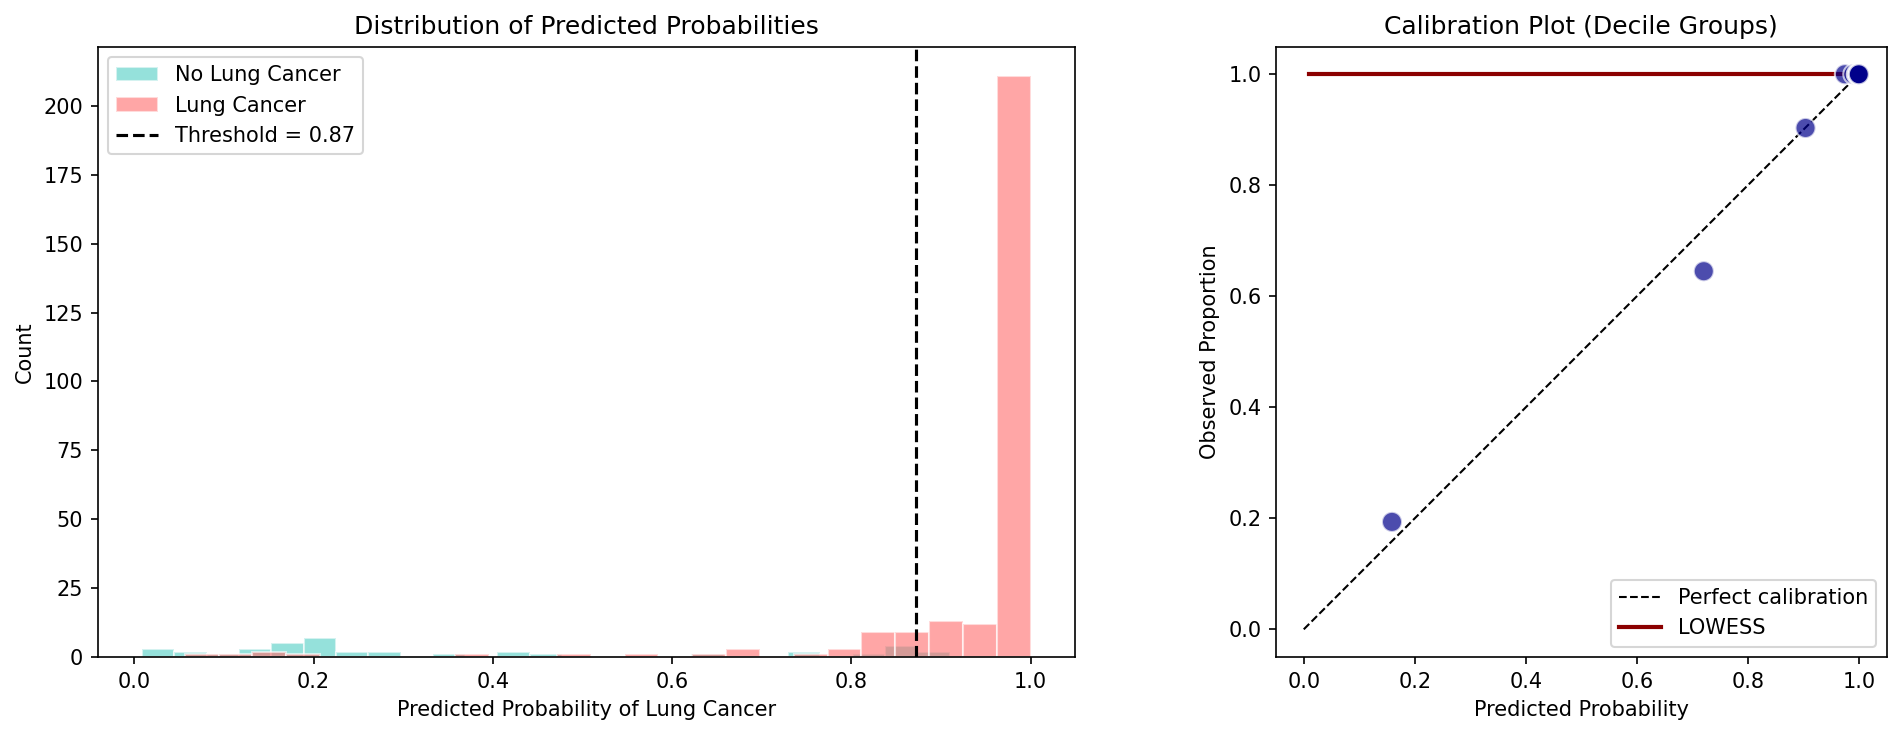

Saved: fig7_calibration_distribution.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Predicted probability distribution
pred_probs = model.predict(df_model[predictor_cols_clean])
for label, val, color in [("No Lung Cancer", 0, "#4ECDC4"), ("Lung Cancer", 1, "#FF6B6B")]:
    subset_probs = pred_probs[df_model["LUNG_CANCER_BIN"] == val]
    axes[0].hist(subset_probs, bins=25, alpha=0.6, color=color, label=label, edgecolor="white")
axes[0].axvline(x=optimal_threshold, color="black", linestyle="--", linewidth=1.5,
                label=f"Threshold = {optimal_threshold:.2f}")
axes[0].set_xlabel("Predicted Probability of Lung Cancer")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Predicted Probabilities")
axes[0].legend()

# Right: Calibration plot (deciles)
cal_df = pd.DataFrame({"pred": pred_probs, "obs": df_model["LUNG_CANCER_BIN"]})
cal_df["decile"] = pd.qcut(cal_df["pred"], q=10, duplicates="drop")
cal_grouped = cal_df.groupby("decile", observed=True).agg(
    pred_mean=("pred", "mean"),
    obs_mean=("obs", "mean"),
    n=("obs", "count")
).reset_index()

axes[1].scatter(cal_grouped["pred_mean"], cal_grouped["obs_mean"],
                s=cal_grouped["n"]*3, color="darkblue", alpha=0.7, edgecolors="white", zorder=5)
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
# Lowess smoothing line
from statsmodels.nonparametric.smoothers_lowess import lowess
smooth = lowess(cal_df["obs"], cal_df["pred"], frac=0.6)
axes[1].plot(smooth[:, 0], smooth[:, 1], color="darkred", linewidth=2, label="LOWESS")
axes[1].set_xlabel("Predicted Probability")
axes[1].set_ylabel("Observed Proportion")
axes[1].set_title("Calibration Plot (Decile Groups)")
axes[1].legend()
axes[1].set_xlim([-0.05, 1.05])
axes[1].set_ylim([-0.05, 1.05])
axes[1].set_aspect("equal")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig7_calibration_distribution.png", bbox_inches="tight")
plt.show()
print(f"Saved: fig7_calibration_distribution.png")

## 17. Risk Factor Clustering Heatmap

Hierarchical clustering of patients based on their risk factor profiles, visualized as a clustermap with lung cancer status annotation.

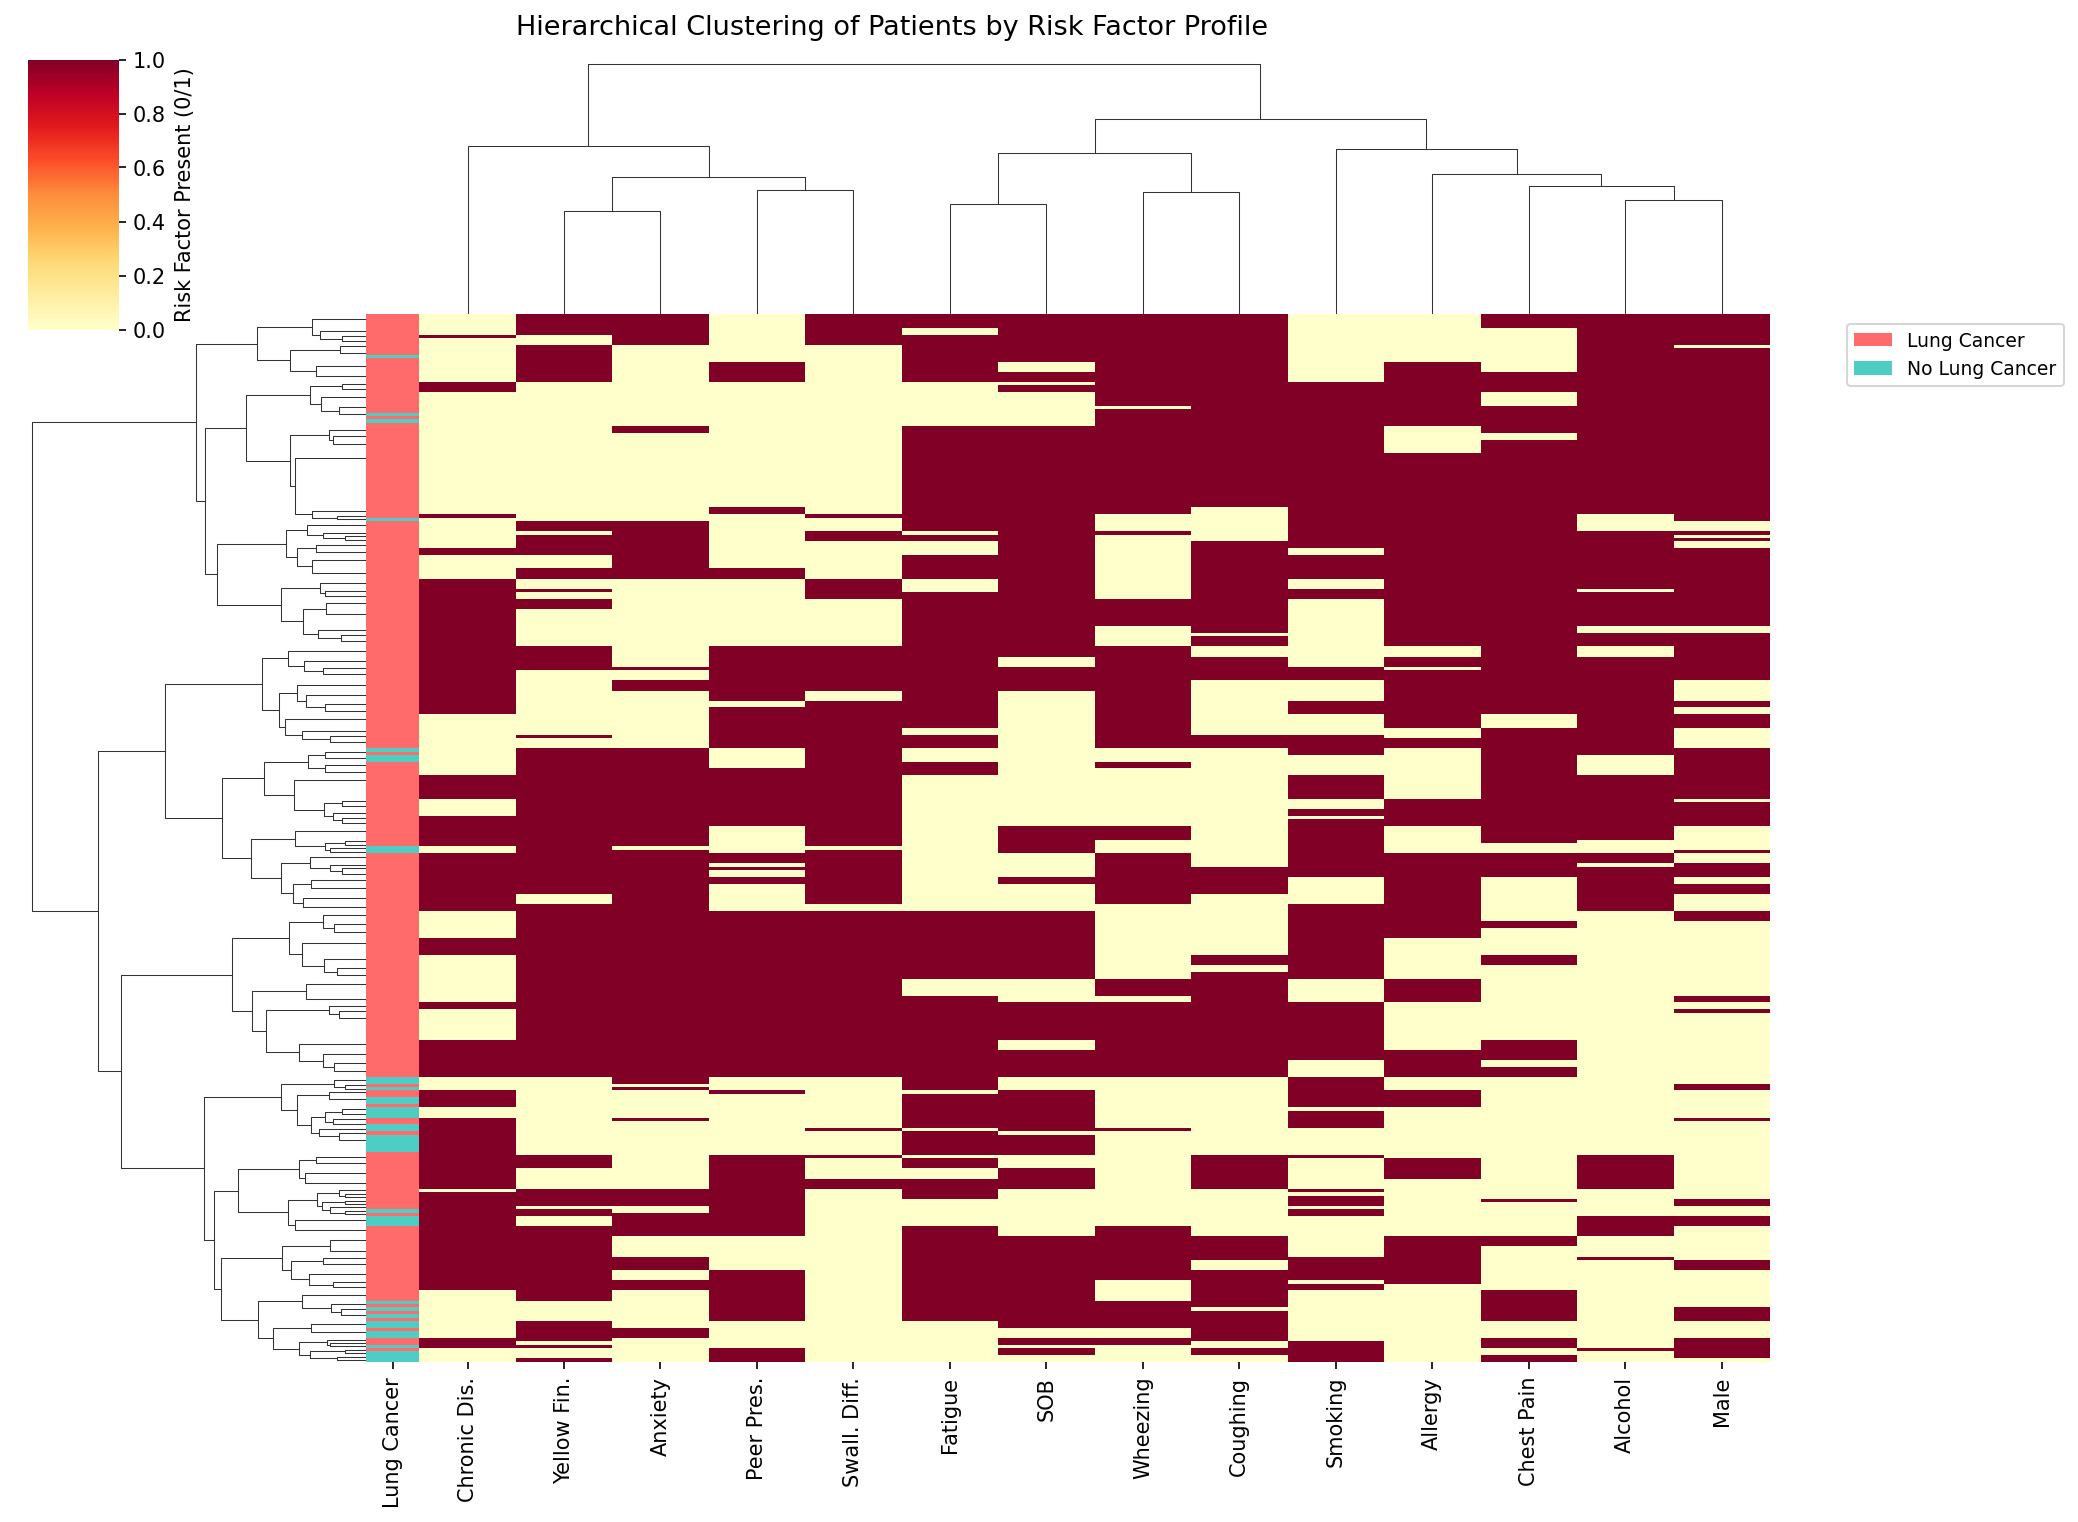

Saved: fig8_clustermap.png


In [17]:
# Prepare data for clustermap
cluster_data = df[binary_vars + ["GENDER_BIN"]].copy()
cluster_data.columns = ["Smoking", "Yellow Fin.", "Anxiety", "Peer Pres.", "Chronic Dis.",
                        "Fatigue", "Allergy", "Wheezing", "Alcohol", "Coughing",
                        "SOB", "Swall. Diff.", "Chest Pain", "Male"]

# Row colors by outcome
row_colors = df["LUNG_CANCER_BIN"].map({1: "#FF6B6B", 0: "#4ECDC4"})
row_colors.name = "Lung Cancer"

# Clustermap
g = sns.clustermap(cluster_data, method="ward", metric="euclidean",
                   row_colors=row_colors, col_cluster=True, row_cluster=True,
                   cmap="YlOrRd", figsize=(12, 10), linewidths=0,
                   cbar_kws={"label": "Risk Factor Present (0/1)"},
                   yticklabels=False)
g.fig.suptitle("Hierarchical Clustering of Patients by Risk Factor Profile", y=1.01, fontsize=13)

# Add legend for row colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#FF6B6B", label="Lung Cancer"),
                   Patch(facecolor="#4ECDC4", label="No Lung Cancer")]
g.ax_heatmap.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(1.05, 1.0), fontsize=9)

plt.savefig(FIG_DIR / "fig8_clustermap.png", bbox_inches="tight")
plt.show()
print(f"Saved: fig8_clustermap.png")

## 18. Stepwise Variable Importance: Permutation Importance

Evaluate which predictors contribute most to the logistic regression model using permutation importance (model-agnostic method).

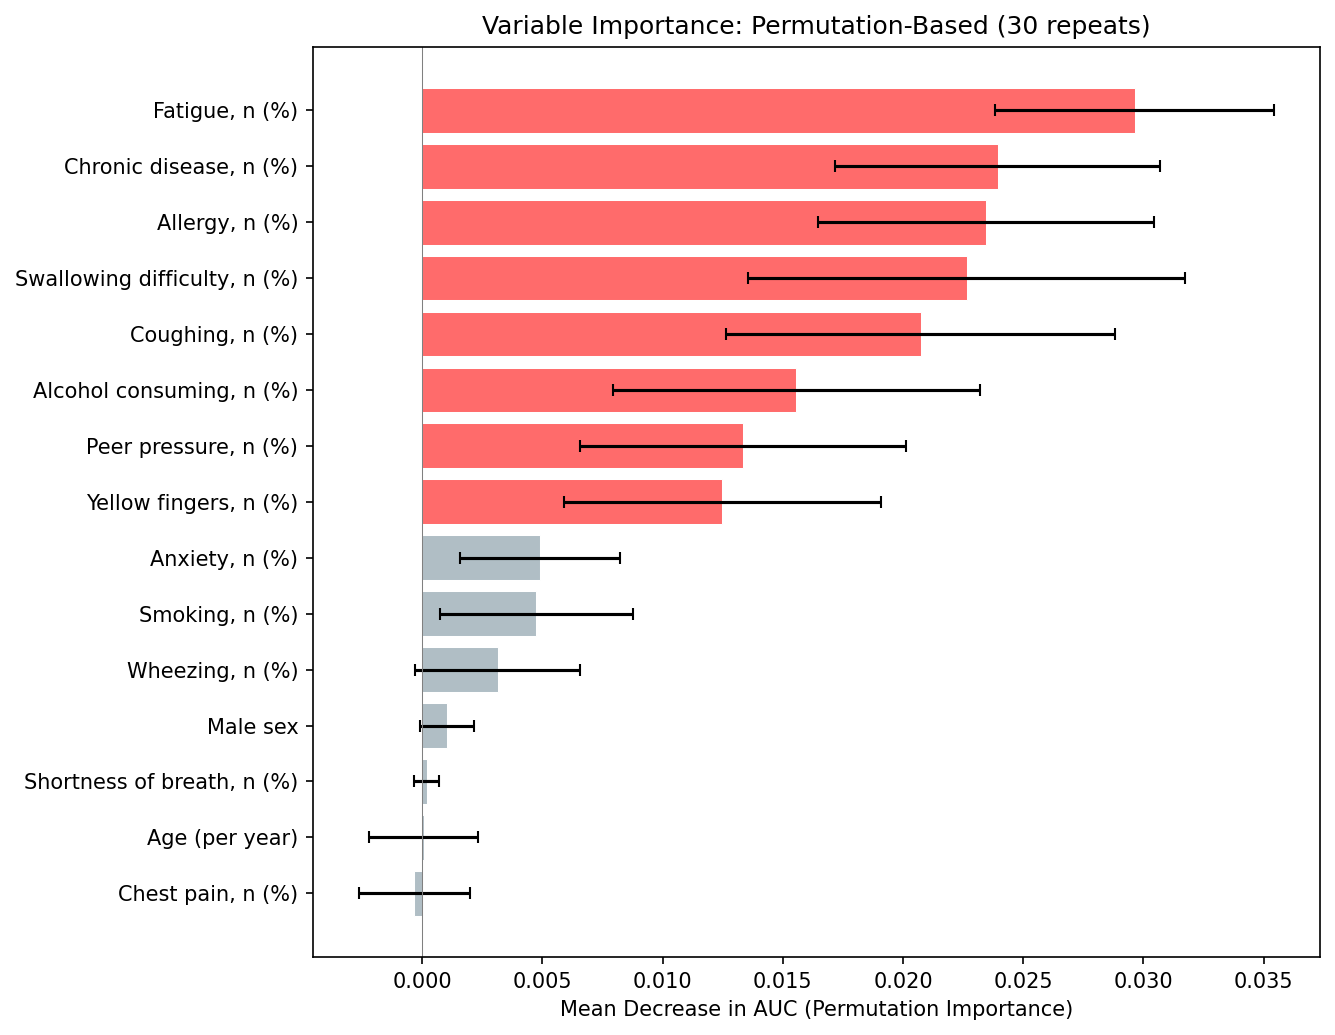

Top 5 most important predictors:
  Fatigue, n (%): 0.0296 ± 0.0058
  Chronic disease, n (%): 0.0239 ± 0.0068
  Allergy, n (%): 0.0234 ± 0.0070
  Swallowing difficulty, n (%): 0.0227 ± 0.0091
  Coughing, n (%): 0.0207 ± 0.0081

Saved: fig9_permutation_importance.png


In [18]:
from sklearn.inspection import permutation_importance

# Fit sklearn model for permutation importance
lr_fitted = LogisticRegression(max_iter=1000, random_state=42).fit(X, y)

# Compute permutation importance
perm_result = permutation_importance(lr_fitted, X, y, n_repeats=30, random_state=42, scoring="roc_auc")

# Organize results
perm_df = pd.DataFrame({
    "Variable": [var_label_map.get(c, c) for c in predictor_cols_clean],
    "Importance_Mean": perm_result.importances_mean,
    "Importance_Std": perm_result.importances_std,
}).sort_values("Importance_Mean", ascending=True)

# Bar plot
fig, ax = plt.subplots(figsize=(9, 7))
colors_imp = ["#FF6B6B" if x > 0.01 else "#B0BEC5" for x in perm_df["Importance_Mean"]]
ax.barh(range(len(perm_df)), perm_df["Importance_Mean"],
        xerr=perm_df["Importance_Std"], color=colors_imp,
        edgecolor="white", linewidth=0.5, capsize=3)
ax.set_yticks(range(len(perm_df)))
ax.set_yticklabels(perm_df["Variable"])
ax.set_xlabel("Mean Decrease in AUC (Permutation Importance)")
ax.set_title("Variable Importance: Permutation-Based (30 repeats)")
ax.axvline(x=0, color="gray", linewidth=0.5)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig9_permutation_importance.png", bbox_inches="tight")
plt.show()

print("Top 5 most important predictors:")
top5 = perm_df.tail(5).iloc[::-1]
for _, r in top5.iterrows():
    print(f"  {r['Variable']}: {r['Importance_Mean']:.4f} ± {r['Importance_Std']:.4f}")
print(f"\nSaved: fig9_permutation_importance.png")